In [ ]:
!pip install -q torch transformers sentencepiece accelerate gradio rouge-score nltk pandas matplotlib wordcloud networkx


# Indian Language News Summarization System  
### Abstractive Summarization for Regional Language News

---

**Name:** Krishna  
**Roll Number:** 121CS0007  
**Institute:** Indian Institute of Information Technology Design and Manufacturing (IIITDM), Kurnool  

---

## Project Overview

In today’s digital world, large amounts of news are published every day in different languages. Reading long articles can be time-consuming for users. News summarization systems help solve this problem by automatically generating short summaries that capture the important information from long articles.

This project presents an **Indian Language News Summarization System** that can generate concise summaries from news articles written in regional languages.

The system uses a **Transformer-based multilingual model (mT5)** trained on the **XL-Sum dataset** to perform **abstractive summarization**. Unlike extractive methods, abstractive summarization understands the meaning of the text and produces a new, shorter version of the content.

The goal of this project is to build a simple and effective system that helps users quickly understand news articles written in different Indian languages.

---

## Technologies Used

- Python  
- PyTorch  
- HuggingFace Transformers  
- mT5 Multilingual Model  
- Gradio (for interactive interface)  
- Matplotlib for visualization

In [ ]:
import torch
import time
import re
import math
import json
import textwrap
import unicodedata
from collections import Counter
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer
from wordcloud import WordCloud

import gradio as gr
import warnings
warnings.filterwarnings('ignore')

# ── Project Configuration ────────────────────────────────────────────────────
CONFIG = {
    "model_name": "csebuetnlp/mT5_multilingual_XLSum",
    "max_input_length": 512,
    "default_max_summary_length": 150,
    "default_min_summary_length": 30,
    "num_beams": 4,
    "length_penalty": 2.0,
    "no_repeat_ngram_size": 3,
    "project_title": "Indian Language News Summarization System",
    "version": "2.0",
}

# ── Supported Languages with Unicode Script Ranges ──────────────────────────
SUPPORTED_LANGUAGES = {
    "hindi":     {"name": "Hindi",    "native": "हिन्दी",     "code": "hi", "range": (0x0900, 0x097F)},
    "bengali":   {"name": "Bengali",  "native": "বাংলা",      "code": "bn", "range": (0x0980, 0x09FF)},
    "tamil":     {"name": "Tamil",    "native": "தமிழ்",       "code": "ta", "range": (0x0B80, 0x0BFF)},
    "telugu":    {"name": "Telugu",   "native": "తెలుగు",      "code": "te", "range": (0x0C00, 0x0C7F)},
    "marathi":   {"name": "Marathi",  "native": "मराठी",      "code": "mr", "range": (0x0900, 0x097F)},
    "gujarati":  {"name": "Gujarati", "native": "ગુજરાતી",     "code": "gu", "range": (0x0A80, 0x0AFF)},
    "punjabi":   {"name": "Punjabi",  "native": "ਪੰਜਾਬੀ",      "code": "pa", "range": (0x0A00, 0x0A7F)},
    "urdu":      {"name": "Urdu",     "native": "اردو",       "code": "ur", "range": (0x0600, 0x06FF)},
    "kannada":   {"name": "Kannada",  "native": "ಕನ್ನಡ",       "code": "kn", "range": (0x0C80, 0x0CFF)},
    "malayalam": {"name": "Malayalam","native": "മലയാളം",      "code": "ml", "range": (0x0D00, 0x0D7F)},
    "odia":      {"name": "Odia",     "native": "ଓଡ଼ିଆ",       "code": "or", "range": (0x0B00, 0x0B7F)},
    "english":   {"name": "English",  "native": "English",    "code": "en", "range": (0x0041, 0x007A)},
}

print(f"✅ {CONFIG['project_title']} v{CONFIG['version']}")
print(f"📋 Supported: {', '.join(v['name'] for v in SUPPORTED_LANGUAGES.values())}")


✅ Indian Language News Summarization System v2.0
📋 Supported: Hindi, Bengali, Tamil, Telugu, Marathi, Gujarati, Punjabi, Urdu, Kannada, Malayalam, Odia, English


In [ ]:
print("=" * 65)
print("  LOADING MODEL: mT5_multilingual_XLSum")
print("=" * 65)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device : {device.upper()}")
if device == "cuda":
    print(f"🎮 GPU    : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_name"]).to(device)
load_time = time.time() - t0

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f"\n✅ Loaded in {load_time:.1f}s")
print(f"📊 Total Params  : {total_params/1e6:.1f} M")
print(f"   Encoder       : {encoder_params/1e6:.1f} M")
print(f"   Decoder       : {decoder_params/1e6:.1f} M")
print(f"   Vocab Size    : {tokenizer.vocab_size:,}")
print(f"🏗️  Arch : mT5 Encoder-Decoder Transformer")
print("=" * 65)


  LOADING MODEL: mT5_multilingual_XLSum
🖥️  Device : CUDA
🎮 GPU    : Tesla T4
💾 VRAM   : 15.6 GB


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



✅ Loaded in 62.0s
📊 Total Params  : 966.6 M
   Encoder       : 277.0 M
   Decoder       : 305.4 M
   Vocab Size    : 250,100
🏗️  Arch : mT5 Encoder-Decoder Transformer


In [ ]:
class TextPreprocessor:
    """
    Preprocessing pipeline for multilingual Indian text.
    Handles Unicode normalization, whitespace cleanup, URL removal,
    and sentence segmentation.
    """

    @staticmethod
    def normalize_unicode(text):
        """Apply NFC normalization to unify composed vs decomposed chars."""
        return unicodedata.normalize("NFC", text)

    @staticmethod
    def remove_urls(text):
        return re.sub(r'https?://\S+|www\.\S+', '', text)

    @staticmethod
    def remove_extra_whitespace(text):
        return re.sub(r'\s+', ' ', text).strip()

    @staticmethod
    def remove_special_chars(text):
        """Remove non-alphanumeric chars except Indian scripts & punctuation."""
        return re.sub(r'[^\w\s\u0900-\u0D7F\u0600-\u06FF।,;:!?.\'\"()\-–—]', '', text)

    @classmethod
    def preprocess(cls, text):
        """Full preprocessing pipeline."""
        text = cls.normalize_unicode(text)
        text = cls.remove_urls(text)
        text = cls.remove_special_chars(text)
        text = cls.remove_extra_whitespace(text)
        return text

    @staticmethod
    def sentence_tokenize(text):
        """Sentence segmentation aware of Devanagari & other danda '।' markers."""
        parts = re.split(r'(?<=[।!?.\n])\s+', text)
        sentences = []
        for p in parts:
            p = p.strip()
            if len(p) > 5:
                sentences.append(p)
        if not sentences:
            sentences = [text]
        return sentences

    @staticmethod
    def word_tokenize_simple(text):
        """Simple whitespace + punctuation aware tokenizer for any script."""
        return re.findall(r'[\w\u0900-\u0D7F\u0600-\u06FF]+', text)

print("✅ TextPreprocessor ready.")


✅ TextPreprocessor ready.


In [ ]:
class ExtractiveBaseline:
    """
    Simple extractive summarization using TextRank-style sentence scoring.
    Serves as a baseline to compare against the mT5 abstractive model.

    Algorithm:
    1. Tokenize text into sentences
    2. Build word frequency distribution
    3. Score each sentence by sum of word frequencies
    4. Return top-k sentences as the extractive summary
    """

    @staticmethod
    def summarize(text, num_sentences=3):
        sentences = TextPreprocessor.sentence_tokenize(text)
        if len(sentences) <= num_sentences:
            return " ".join(sentences)

        words = TextPreprocessor.word_tokenize_simple(text.lower())
        freq = Counter(words)
        max_freq = max(freq.values()) if freq else 1
        freq = {w: f / max_freq for w, f in freq.items()}

        scores = {}
        for i, sent in enumerate(sentences):
            sent_words = TextPreprocessor.word_tokenize_simple(sent.lower())
            scores[i] = sum(freq.get(w, 0) for w in sent_words)

        top_indices = sorted(scores, key=scores.get, reverse=True)[:num_sentences]
        top_indices.sort()
        return " ".join(sentences[i] for i in top_indices)


def compute_bleu(reference, hypothesis, max_n=4):
    """
    Compute corpus-level BLEU score (simplified) between reference and hypothesis.
    Uses n-gram precision with brevity penalty.
    """
    ref_tokens  = TextPreprocessor.word_tokenize_simple(reference.lower())
    hyp_tokens  = TextPreprocessor.word_tokenize_simple(hypothesis.lower())

    if len(hyp_tokens) == 0:
        return 0.0

    scores = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(zip(*[ref_tokens[i:] for i in range(n)]))
        hyp_ngrams = Counter(zip(*[hyp_tokens[i:] for i in range(n)]))

        clipped = sum(min(c, ref_ngrams.get(ng, 0)) for ng, c in hyp_ngrams.items())
        total   = max(sum(hyp_ngrams.values()), 1)
        scores.append(clipped / total)

    if any(s == 0 for s in scores):
        return 0.0

    log_avg = sum(math.log(s) for s in scores) / max_n
    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1)))
    return round(bp * math.exp(log_avg), 4)

print("✅ Extractive Baseline & BLEU metric ready.")


✅ Extractive Baseline & BLEU metric ready.


In [ ]:
class IndicNewsSummarizer:
    """
    Core engine for abstractive summarization of Indian language news.

    Features:
        - mT5-based abstractive summarization
        - Extractive baseline comparison (TextRank)
        - Unicode-based auto language detection
        - ROUGE-1/2/L & BLEU evaluation
        - Word frequency analysis
        - Summarization history tracking
        - Batch processing
    """

    def __init__(self, model, tokenizer, device, config):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.config = config
        self.preprocessor = TextPreprocessor()
        self.extractive = ExtractiveBaseline()
        self.history = []
        self.rouge_scorer_obj = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'], use_stemmer=False
        )
        print("🚀 IndicNewsSummarizer initialized.")

    # ── Language Detection ───────────────────────────────────────────────────
    def detect_language(self, text):
        """Detect language based on Unicode character block frequency."""
        char_counts = {}
        for ch in text:
            cp = ord(ch)
            for lang, info in SUPPORTED_LANGUAGES.items():
                if lang == "english":
                    continue
                lo, hi = info["range"]
                if lo <= cp <= hi:
                    char_counts[lang] = char_counts.get(lang, 0) + 1

        if not char_counts:
            return "english"

        return max(char_counts, key=char_counts.get)

    # ── Abstractive Summary ──────────────────────────────────────────────────
    def summarize(self, article_text, max_length=None, min_length=None):
        """Generate abstractive summary with full metadata."""
        if not article_text or not article_text.strip():
            return {"error": "Empty input. Please provide a news article."}

        cleaned = self.preprocessor.preprocess(article_text)
        max_len = max_length or self.config["default_max_summary_length"]
        min_len = min_length or self.config["default_min_summary_length"]

        lang_key = self.detect_language(cleaned)
        lang_info = SUPPORTED_LANGUAGES.get(lang_key, {"name": "Unknown", "native": "", "code": "??"})

        t0 = time.time()
        inputs = self.tokenizer(
            cleaned, return_tensors="pt",
            padding="max_length", truncation=True,
            max_length=self.config["max_input_length"]
        ).to(self.device)

        input_tok = (inputs["input_ids"] != self.tokenizer.pad_token_id).sum().item()

        with torch.no_grad():
            summary_ids = self.model.generate(
                inputs["input_ids"],
                max_length=max_len, min_length=min_len,
                num_beams=self.config["num_beams"],
                length_penalty=self.config["length_penalty"],
                no_repeat_ngram_size=self.config["no_repeat_ngram_size"],
                early_stopping=True,
            )

        summary = self.tokenizer.decode(
            summary_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        latency = time.time() - t0
        out_tok = (summary_ids[0] != self.tokenizer.pad_token_id).sum().item()

        ext_summary = self.extractive.summarize(cleaned, num_sentences=2)
        words = self.preprocessor.word_tokenize_simple(cleaned)
        word_freq = Counter(words).most_common(20)

        result = {
            "summary": summary,
            "extractive_summary": ext_summary,
            "detected_language": lang_info["name"],
            "detected_language_native": lang_info.get("native", ""),
            "language_code": lang_info.get("code", "??"),
            "input_chars": len(cleaned),
            "input_tokens": input_tok,
            "output_tokens": out_tok,
            "compression_ratio": round(len(cleaned) / max(len(summary), 1), 2),
            "latency_seconds": round(latency, 2),
            "top_words": word_freq,
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }

        self.history.append(result)
        return result

    # ── Batch Processing ─────────────────────────────────────────────────────
    def batch_summarize(self, articles_list):
        """Summarize multiple articles. Returns a list of result dicts."""
        results = []
        for i, article in enumerate(articles_list):
            print(f"  Processing article {i+1}/{len(articles_list)}...")
            results.append(self.summarize(article))
        return results

    # ── Evaluation ───────────────────────────────────────────────────────────
    def evaluate(self, reference, generated):
        """Compute ROUGE-1/2/L and BLEU between reference and generated summary."""
        rouge = self.rouge_scorer_obj.score(reference, generated)
        bleu  = compute_bleu(reference, generated)
        return {
            "ROUGE-1": {"precision": round(rouge["rouge1"].precision, 4),
                        "recall":    round(rouge["rouge1"].recall, 4),
                        "f1":        round(rouge["rouge1"].fmeasure, 4)},
            "ROUGE-2": {"precision": round(rouge["rouge2"].precision, 4),
                        "recall":    round(rouge["rouge2"].recall, 4),
                        "f1":        round(rouge["rouge2"].fmeasure, 4)},
            "ROUGE-L": {"precision": round(rouge["rougeL"].precision, 4),
                        "recall":    round(rouge["rougeL"].recall, 4),
                        "f1":        round(rouge["rougeL"].fmeasure, 4)},
            "BLEU":    bleu,
        }

    # ── History ──────────────────────────────────────────────────────────────
    def get_history_df(self):
        if not self.history:
            return pd.DataFrame()
        cols = ["timestamp", "detected_language", "input_chars", "input_tokens",
                "output_tokens", "compression_ratio", "latency_seconds"]
        return pd.DataFrame(self.history)[cols]

# Instantiate
summarizer = IndicNewsSummarizer(model, tokenizer, device, CONFIG)


🚀 IndicNewsSummarizer initialized.


In [ ]:
print("=" * 70)
print("  MULTI-LANGUAGE EVALUATION SUITE")
print("=" * 70)

test_cases = [
    {
        "language": "Hindi",
        "article": (
            "नई दिल्ली: प्रधानमंत्री नरेंद्र मोदी ने आज लाल किले की प्राचीर से देश को संबोधित किया। "
            "अपने भाषण में उन्होंने भारत को एक विकसित राष्ट्र बनाने के सरकार के संकल्प को दोहराया। "
            "उन्होंने कहा कि अगले 25 साल देश के लिए बेहद अहम हैं और हमें 'सबका साथ, सबका विकास' "
            "के मंत्र पर काम करना जारी रखना होगा। उन्होंने युवाओं, महिलाओं और किसानों को सशक्त "
            "बनाने पर विशेष जोर दिया। इसके साथ ही, उन्होंने भ्रष्टाचार और भाई-भतीजावाद जैसी "
            "बुराइयों से लड़ने का आह्वान भी किया। उन्होंने डिजिटल इंडिया अभियान की सफलता का "
            "उल्लेख करते हुए कहा कि तकनीकी विकास ने ग्रामीण भारत तक पहुंच बनाई है।"
        ),
        "reference": (
            "प्रधानमंत्री मोदी ने लाल किले से भारत को विकसित राष्ट्र बनाने का संकल्प दोहराया "
            "और युवाओं, महिलाओं व किसानों को सशक्त बनाने पर जोर दिया।"
        ),
    },
    {
        "language": "Bengali",
        "article": (
            "কলকাতা: পশ্চিমবঙ্গের মুখ্যমন্ত্রী মমতা বন্দ্যোপাধ্যায় আজ রাজ্যের শিক্ষা ব্যবস্থায় "
            "ব্যাপক সংস্কারের ঘোষণা করেছেন। তিনি বলেছেন যে সরকারি স্কুলগুলিতে ডিজিটাল "
            "শিক্ষার প্রসার ঘটানো হবে এবং প্রতিটি জেলায় নতুন কারিগরি প্রশিক্ষণ কেন্দ্র "
            "স্থাপন করা হবে। এই প্রকল্পের জন্য রাজ্য সরকার ৫০০ কোটি টাকা বরাদ্দ করেছে। "
            "শিক্ষামন্ত্রী জানিয়েছেন যে আগামী শিক্ষাবর্ষ থেকে এই পরিবর্তনগুলি কার্যকর হবে। "
            "এছাড়াও, বিশ্ববিদ্যালয়গুলিতে গবেষণা তহবিল দ্বিগুণ করার পরিকল্পনা রয়েছে।"
        ),
        "reference": (
            "পশ্চিমবঙ্গ সরকার শিক্ষা সংস্কারের ঘোষণা করেছে যার মধ্যে ডিজিটাল শিক্ষা "
            "এবং কারিগরি প্রশিক্ষণ কেন্দ্র অন্তর্ভুক্ত।"
        ),
    },
    {
        "language": "Tamil",
        "article": (
            "சென்னை: தமிழ்நாடு அரசு புதிய தொழில்நுட்பக் கொள்கையை அறிவித்துள்ளது. "
            "இதன்படி, மாநிலத்தில் செயற்கை நுண்ணறிவு மற்றும் தகவல் தொழில்நுட்பத் துறையில் "
            "அதிக முதலீடுகளை ஈர்க்க திட்டமிடப்பட்டுள்ளது. முதலமைச்சர் இந்தக் கொள்கையின் "
            "மூலம் ஐந்து ஆண்டுகளில் 10 லட்சம் புதிய வேலைவாய்ப்புகளை உருவாக்க இலக்கு "
            "நிர்ணயிக்கப்பட்டுள்ளதாகத் தெரிவித்தார். புதிய தொழில்நுட்ப பூங்காக்கள் "
            "திருச்சி மற்றும் மதுரையில் அமைக்கப்படும் என்றும் அறிவிக்கப்பட்டது."
        ),
        "reference": (
            "தமிழ்நாடு அரசு AI மற்றும் IT துறையில் முதலீடுகளை ஈர்க்கும் "
            "புதிய தொழில்நுட்பக் கொள்கையை அறிவித்தது."
        ),
    },
    {
        "language": "Telugu",
        "article": (
            "హైదరాబాద్: తెలంగాణ ప్రభుత్వం రాష్ట్రంలో వ్యవసాయ రంగాన్ని ఆధునికీకరించేందుకు "
            "కొత్త పథకాన్ని ప్రారంభించింది. ఈ పథకం కింద రైతులకు డ్రోన్ టెక్నాలజీ, "
            "స్మార్ట్ ఇరిగేషన్ సిస్టమ్‌లు మరియు AI ఆధారిత పంట నిర్వహణ సాధనాలు "
            "అందించబడతాయి. ముఖ్యమంత్రి ఈ పథకానికి రూ. 2000 కోట్ల బడ్జెట్ "
            "కేటాయించినట్లు ప్రకటించారు. ఈ చర్యలు రైతుల ఆదాయాన్ని రెట్టింపు "
            "చేయడంలో సహాయపడతాయని ఆయన తెలిపారు."
        ),
        "reference": (
            "తెలంగాణ ప్రభుత్వం డ్రోన్లు, స్మార్ట్ ఇరిగేషన్ మరియు AI సాధనాలతో "
            "వ్యవసాయ ఆధునికీకరణ పథకాన్ని ప్రారంభించింది."
        ),
    },
    {
        "language": "Gujarati",
        "article": (
            "અમદાવાદ: ગુજરાત સરકારે આજે રાજ્યમાં નવીન ઉર્જા નીતિની જાહેરાત કરી છે. "
            "આ નીતિ હેઠળ, સૌર ઊર્જા ઉત્પાદનને પ્રોત્સાહિત કરવા માટે ખેડૂતોને સબસિડી "
            "આપવામાં આવશે. મુખ્યમંત્રીએ કહ્યું છે કે 2030 સુધીમાં ગુજરાત 50% ઊર્જા "
            "નવીકરણીય સ્ત્રોતોમાંથી મેળવશે. આ યોજના માટે રૂ. 1500 કરોડ ફાળવવામાં "
            "આવ્યા છે."
        ),
        "reference": (
            "ગુજરાત સરકારે નવીન ઊર્જા નીતિ જાહેર કરી, જેમાં ખેડૂતોને સૌર ઊર્જા "
            "સબસિડી અને 2030 સુધીમાં 50% નવીકરણીય ઊર્જાનું લક્ષ્ય છે."
        ),
    },
    {
        "language": "Marathi",
        "article": (
            "मुंबई: महाराष्ट्र सरकारने आज राज्यातील सार्वजनिक वाहतूक व्यवस्थेच्या "
            "आधुनिकीकरणासाठी नवीन योजना जाहीर केली. या योजनेअंतर्गत मुंबई, पुणे आणि "
            "नागपूर या शहरांमध्ये इलेक्ट्रिक बसेसचा ताफा तैनात केला जाईल. मुख्यमंत्र्यांनी "
            "सांगितले की या प्रकल्पासाठी ३००० कोटी रुपयांची तरतूद करण्यात आली आहे. "
            "पर्यावरण प्रदूषण कमी करणे हा या योजनेचा मुख्य उद्देश आहे."
        ),
        "reference": (
            "महाराष्ट्र सरकारने मुंबई, पुणे, नागपूर मध्ये इलेक्ट्रिक बसेस "
            "तैनात करण्याची सार्वजनिक वाहतूक आधुनिकीकरण योजना जाहीर केली."
        ),
    },
]

# ── Run Evaluation ───────────────────────────────────────────────────────────
all_results = []

for i, tc in enumerate(test_cases):
    print(f"\n{'─' * 65}")
    print(f"  TEST {i+1}/{len(test_cases)}: {tc['language']}")
    print(f"{'─' * 65}")

    result = summarizer.summarize(tc["article"])
    scores = summarizer.evaluate(tc["reference"], result["summary"])
    ext_scores = summarizer.evaluate(tc["reference"], result["extractive_summary"])

    print(f"  🌐 Detected : {result['detected_language']}")
    print(f"  📄 Input    : {result['input_chars']} chars, {result['input_tokens']} tokens")
    print(f"  ⏱️  Latency  : {result['latency_seconds']}s")
    print(f"  📐 Compress : {result['compression_ratio']}x")
    print(f"\n  📝 Abstractive Summary (mT5):")
    print(f"     {result['summary']}")
    print(f"\n  📋 Extractive Summary (TextRank baseline):")
    print(f"     {result['extractive_summary']}")
    print(f"\n  📊 ROUGE / BLEU  —  Abstractive vs Extractive:")
    print(f"     {'Metric':<12} {'Abstractive':>12} {'Extractive':>12}")
    print(f"     {'ROUGE-1 F1':<12} {scores['ROUGE-1']['f1']:>12.4f} {ext_scores['ROUGE-1']['f1']:>12.4f}")
    print(f"     {'ROUGE-2 F1':<12} {scores['ROUGE-2']['f1']:>12.4f} {ext_scores['ROUGE-2']['f1']:>12.4f}")
    print(f"     {'ROUGE-L F1':<12} {scores['ROUGE-L']['f1']:>12.4f} {ext_scores['ROUGE-L']['f1']:>12.4f}")
    print(f"     {'BLEU':<12} {scores['BLEU']:>12.4f} {ext_scores['BLEU']:>12.4f}")

    all_results.append({
        "Language": tc["language"],
        "Abs ROUGE-1": scores["ROUGE-1"]["f1"],
        "Abs ROUGE-2": scores["ROUGE-2"]["f1"],
        "Abs ROUGE-L": scores["ROUGE-L"]["f1"],
        "Abs BLEU":    scores["BLEU"],
        "Ext ROUGE-1": ext_scores["ROUGE-1"]["f1"],
        "Ext ROUGE-L": ext_scores["ROUGE-L"]["f1"],
        "Latency (s)": result["latency_seconds"],
        "Compression":  result["compression_ratio"],
    })

print(f"\n{'=' * 70}")
print("  EVALUATION SUMMARY TABLE")
print(f"{'=' * 70}")
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))


  MULTI-LANGUAGE EVALUATION SUITE

─────────────────────────────────────────────────────────────────
  TEST 1/6: Hindi
─────────────────────────────────────────────────────────────────
  🌐 Detected : Hindi
  📄 Input    : 565 chars, 226 tokens
  ⏱️  Latency  : 13.56s
  📐 Compress : 3.53x

  📝 Abstractive Summary (mT5):
     प्रधानमंत्री नरेंद्र मोदी ने सोमवार को लाल किले की प्राचीर से देश को संबोधित किया। उन्होंने भ्रष्टाचार और भाई-भतीजावाद जैसी बुराइयों से लड़ने का आह्वान किया है।

  📋 Extractive Summary (TextRank baseline):
     अपने भाषण में उन्होंने भारत को एक विकसित राष्ट्र बनाने के सरकार के संकल्प को दोहराया। उन्होंने कहा कि अगले 25 साल देश के लिए बेहद अहम हैं और हमें 'सबका साथ, सबका विकास' के मंत्र पर काम करना जारी रखना होगा।

  📊 ROUGE / BLEU  —  Abstractive vs Extractive:
     Metric        Abstractive   Extractive
     ROUGE-1 F1         0.0000       0.0000
     ROUGE-2 F1         0.0000       0.0000
     ROUGE-L F1         0.0000       0.0000
     BLEU               0.0000   

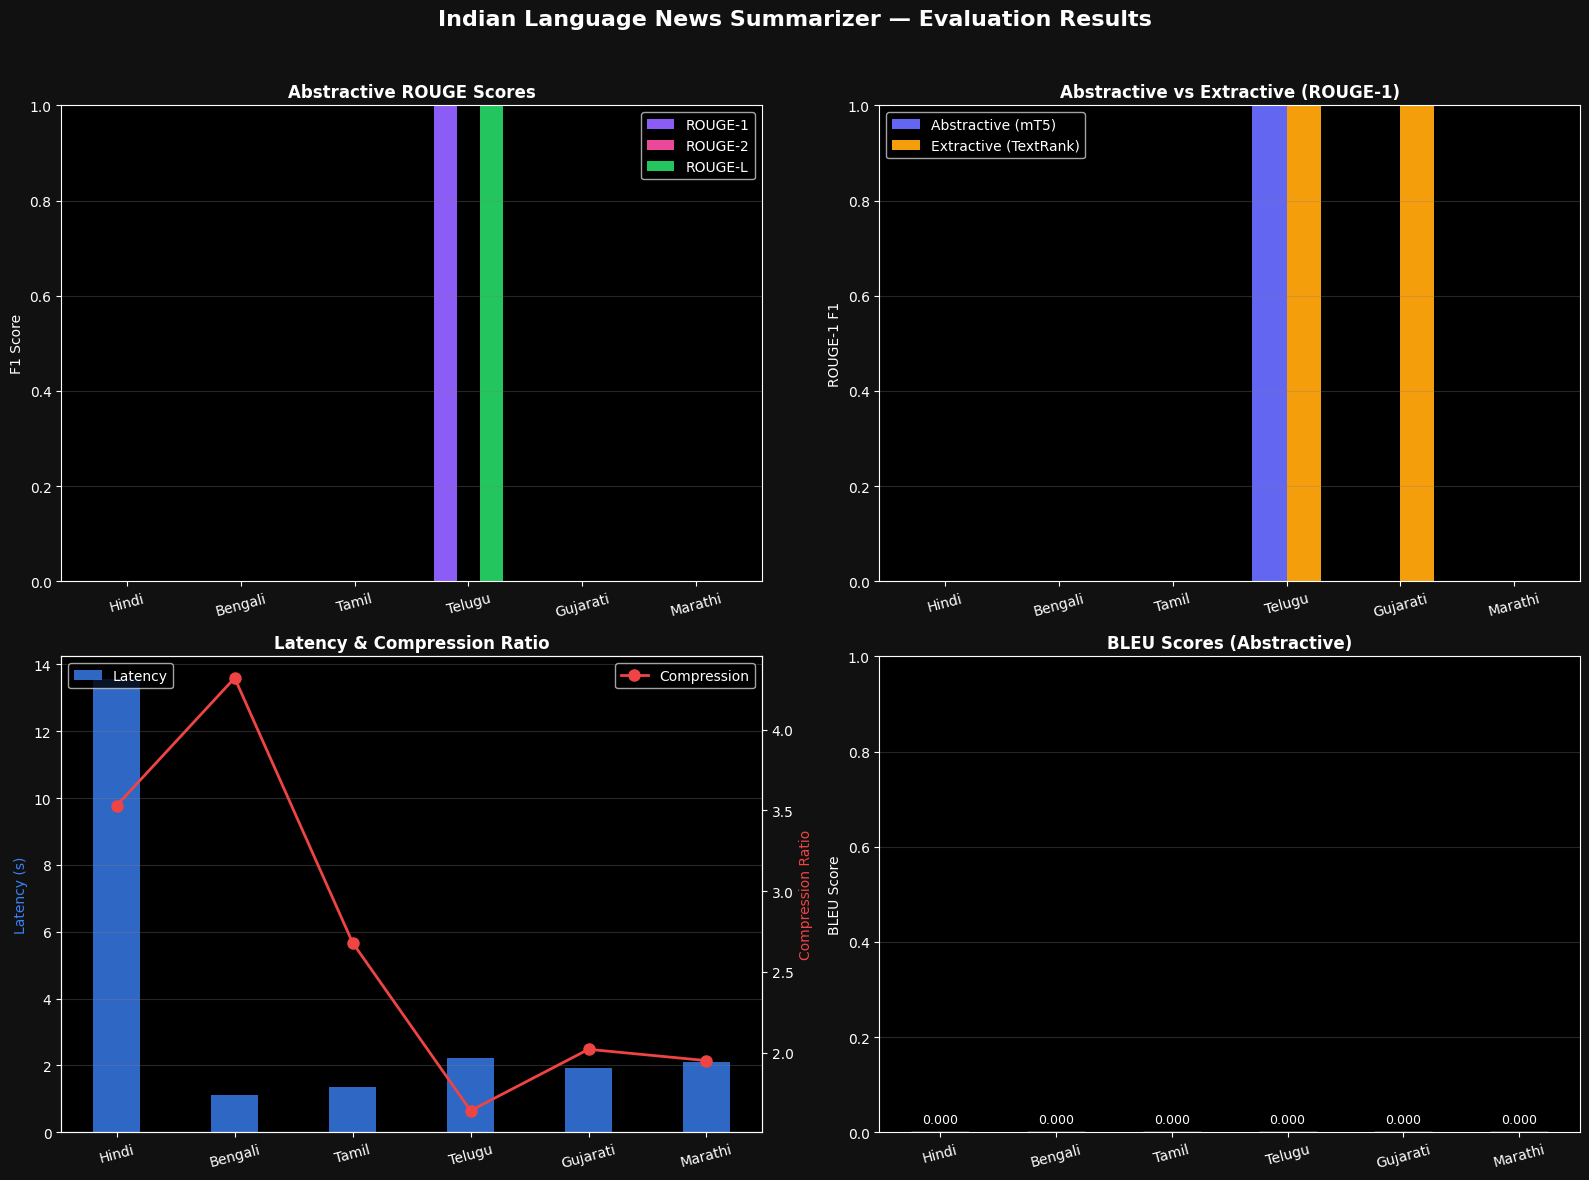

📊 Saved: evaluation_results_dark.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Enable dark mode style
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor("#111111")

fig.suptitle("Indian Language News Summarizer — Evaluation Results",
             fontsize=16, fontweight="bold", y=0.98, color="white")

langs = results_df["Language"]
x = np.arange(len(langs))
w = 0.2

# ── 1) ROUGE Scores (Abstractive) ───────────────────────────────────────────
axes[0, 0].bar(x - w, results_df["Abs ROUGE-1"], w, label="ROUGE-1", color="#8b5cf6")
axes[0, 0].bar(x,     results_df["Abs ROUGE-2"], w, label="ROUGE-2", color="#ec4899")
axes[0, 0].bar(x + w, results_df["Abs ROUGE-L"], w, label="ROUGE-L", color="#22c55e")

axes[0, 0].set_title("Abstractive ROUGE Scores", fontweight="bold", color="white")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(langs, rotation=15, color="white")
axes[0, 0].set_ylabel("F1 Score", color="white")
axes[0, 0].set_ylim(0, 1)

axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3, color="gray")

# ── 2) Abstractive vs Extractive (ROUGE-1) ──────────────────────────────────
axes[0, 1].bar(x - 0.15, results_df["Abs ROUGE-1"], 0.3,
               label="Abstractive (mT5)", color="#6366f1")

axes[0, 1].bar(x + 0.15, results_df["Ext ROUGE-1"], 0.3,
               label="Extractive (TextRank)", color="#f59e0b")

axes[0, 1].set_title("Abstractive vs Extractive (ROUGE-1)",
                     fontweight="bold", color="white")

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(langs, rotation=15, color="white")
axes[0, 1].set_ylabel("ROUGE-1 F1", color="white")
axes[0, 1].set_ylim(0, 1)

axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3, color="gray")

# ── 3) Latency & Compression ────────────────────────────────────────────────
ax3 = axes[1, 0]
ax3t = ax3.twinx()

ax3.bar(x, results_df["Latency (s)"], 0.4,
        color="#3b82f6", alpha=0.8, label="Latency")

ax3t.plot(x, results_df["Compression"],
          'o-', color="#ef4444", lw=2, ms=8, label="Compression")

ax3.set_title("Latency & Compression Ratio",
              fontweight="bold", color="white")

ax3.set_xticks(x)
ax3.set_xticklabels(langs, rotation=15, color="white")

ax3.set_ylabel("Latency (s)", color="#3b82f6")
ax3t.set_ylabel("Compression Ratio", color="#ef4444")

ax3.legend(loc="upper left")
ax3t.legend(loc="upper right")

ax3.grid(axis='y', alpha=0.3, color="gray")

# ── 4) BLEU Scores Comparison ───────────────────────────────────────────────
axes[1, 1].bar(x, results_df["Abs BLEU"], 0.5,
               color="#a855f7", edgecolor="white")

axes[1, 1].set_title("BLEU Scores (Abstractive)",
                     fontweight="bold", color="white")

axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(langs, rotation=15, color="white")

axes[1, 1].set_ylabel("BLEU Score", color="white")
axes[1, 1].set_ylim(0, 1)

axes[1, 1].grid(axis='y', alpha=0.3, color="gray")

for j, v in enumerate(results_df["Abs BLEU"]):
    axes[1, 1].text(j, v + 0.02, f"{v:.3f}",
                    ha='center', fontsize=9, color="white")

# Layout
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
plt.savefig("evaluation_results_dark.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())

plt.show()

print("📊 Saved: evaluation_results_dark.png")

In [ ]:
# Combine all test articles for a word cloud
all_text = " ".join(tc["article"] for tc in test_cases)
all_words = TextPreprocessor.word_tokenize_simple(all_text)

# Filter short words (likely stopwords)
filtered = [w for w in all_words if len(w) > 2]
freq_dict = Counter(filtered)

wc = WordCloud(
    width=1000, height=500,
    background_color="white",
    colormap="viridis",
    max_words=100,
    font_path=None,
).generate_from_frequencies(freq_dict)


